In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json

DATA_DIR = '/content/drive/MyDrive/MIRAGE/data/raw/GSE98320'

clean_df = pd.read_csv(f'{DATA_DIR}/gse98320_master_pathology_labels.csv')
gene_expr_matrix = pd.read_parquet(f'{DATA_DIR}/gse98320_gene_expression.parquet')

with open(f'{DATA_DIR}/selected_genes_per_fold_k1000.json', 'r') as f:
    selected_genes_per_fold = json.load(f)

print("Master table shape:", clean_df.shape)
print("cv_fold present:", 'cv_fold' in clean_df.columns)
print("Selected genes per fold, sizes:", {k: len(v) for k, v in selected_genes_per_fold.items()})

Mounted at /content/drive
Master table shape: (1208, 20)
cv_fold present: True
Selected genes per fold, sizes: {'0': 1000, '1': 1000, '2': 1000, '3': 1000, '4': 1000}


In [2]:
banff_cols = ['g', 'cg', 'i', 'ci', 't', 'ct', 'v', 'cv', 'ah', 'ptc', 'c4d_ordinal']

def preprocess_pathology_fold(clean_df, banff_cols, train_idx, val_idx):
    train_df = clean_df.loc[train_idx, banff_cols].copy()
    val_df = clean_df.loc[val_idx, banff_cols].copy()

    for col in banff_cols:
        train_df[f'{col}_was_missing'] = train_df[col].isna().astype(int)
        val_df[f'{col}_was_missing'] = val_df[col].isna().astype(int)

    medians = train_df[banff_cols].median()
    for col in banff_cols:
        train_df[col] = train_df[col].fillna(medians[col])
        val_df[col] = val_df[col].fillna(medians[col])

    return train_df, val_df, medians


fold_data = {}

for fold in range(5):
    train_idx = clean_df[clean_df['cv_fold'] != fold].index
    val_idx = clean_df[clean_df['cv_fold'] == fold].index

    path_train, path_val, medians = preprocess_pathology_fold(clean_df, banff_cols, train_idx, val_idx)

    train_gsms = clean_df.loc[train_idx, 'GSM'].values
    val_gsms = clean_df.loc[val_idx, 'GSM'].values

    gene_train_raw = gene_expr_matrix[train_gsms].T
    gene_val_raw = gene_expr_matrix[val_gsms].T

    gene_means = gene_train_raw.mean(axis=0)
    gene_stds = gene_train_raw.std(axis=0).replace(0, 1)

    gene_train_scaled = (gene_train_raw - gene_means) / gene_stds
    gene_val_scaled = (gene_val_raw - gene_means) / gene_stds

    # Restrict to this fold's selected 1000 genes right away, since that's all baselines will use
    fold_genes = selected_genes_per_fold[str(fold)]
    gene_train_selected = gene_train_scaled[fold_genes]
    gene_val_selected = gene_val_scaled[fold_genes]

    y_train = clean_df.loc[train_idx, 'mirage_label'].values
    y_val = clean_df.loc[val_idx, 'mirage_label'].values

    fold_data[fold] = {
        'path_train': path_train, 'path_val': path_val,
        'gene_train': gene_train_selected, 'gene_val': gene_val_selected,
        'y_train': y_train, 'y_val': y_val,
        'train_gsms': train_gsms, 'val_gsms': val_gsms,
    }

    print(f"Fold {fold}: gene_train={gene_train_selected.shape}, path_train={path_train.shape}, "
          f"train={len(train_idx)}, val={len(val_idx)}")

Fold 0: gene_train=(966, 1000), path_train=(966, 22), train=966, val=242
Fold 1: gene_train=(966, 1000), path_train=(966, 22), train=966, val=242
Fold 2: gene_train=(967, 1000), path_train=(967, 22), train=967, val=241
Fold 3: gene_train=(967, 1000), path_train=(967, 22), train=967, val=241
Fold 4: gene_train=(966, 1000), path_train=(966, 22), train=966, val=242


In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report

def evaluate_model_across_folds(model_constructor, fold_data, use_pathology=False):
    """
    model_constructor: a no-arg function that returns a fresh, unfitted sklearn-style classifier
    Returns: mean macro-F1, std macro-F1, list of per-fold macro-F1, list of (y_true, y_pred) per fold
    """
    fold_f1_scores = []
    fold_predictions = []

    for fold in range(5):
        if use_pathology:
            X_train = fold_data[fold]['path_train'].values
            X_val = fold_data[fold]['path_val'].values
        else:
            X_train = fold_data[fold]['gene_train'].values
            X_val = fold_data[fold]['gene_val'].values

        y_train = fold_data[fold]['y_train']
        y_val = fold_data[fold]['y_val']

        model = model_constructor()
        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        macro_f1 = f1_score(y_val, preds, average='macro')
        fold_f1_scores.append(macro_f1)
        fold_predictions.append((y_val, preds))

    return np.mean(fold_f1_scores), np.std(fold_f1_scores), fold_f1_scores, fold_predictions


def hyperparameter_sweep(param_name, param_values, model_constructor_fn, fold_data, model_name, use_pathology=False):
    """
    param_values: list of values to try
    model_constructor_fn: function(param_value) -> model_constructor (no-arg function)
    Plots mean macro-F1 (with std as error bars) vs param value, returns results DataFrame
    """
    results = []

    for val in param_values:
        constructor = model_constructor_fn(val)
        mean_f1, std_f1, fold_scores, _ = evaluate_model_across_folds(constructor, fold_data, use_pathology)
        results.append({param_name: val, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1})
        print(f"{param_name}={val}: mean macro-F1={mean_f1:.4f} (+/- {std_f1:.4f})")

    results_df = pd.DataFrame(results)

    plt.figure(figsize=(8, 5))
    plt.errorbar(results_df[param_name].astype(str), results_df['mean_macro_f1'],
                 yerr=results_df['std_macro_f1'], marker='o', capsize=5)
    plt.xlabel(param_name)
    plt.ylabel('Mean Macro-F1 (5-fold CV)')
    plt.title(f'{model_name}: Hyperparameter sweep')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results_df

C=0.001: mean macro-F1=0.1622 (+/- 0.0423)
C=0.01: mean macro-F1=0.6776 (+/- 0.0651)
C=0.1: mean macro-F1=0.7466 (+/- 0.0455)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=1.0: mean macro-F1=0.7411 (+/- 0.0612)
C=10.0: mean macro-F1=0.7283 (+/- 0.0345)


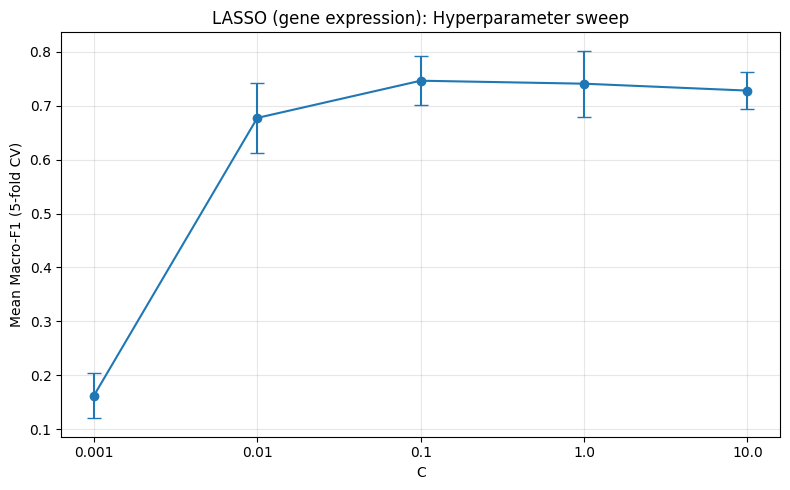

In [4]:
from sklearn.linear_model import LogisticRegression

def make_lasso_constructor(C):
    def constructor():
        return LogisticRegression(
            penalty='l1', solver='saga', C=C,
            class_weight='balanced', max_iter=5000, random_state=42
        )
    return constructor

C_values = [0.001, 0.01, 0.1, 1.0, 10.0]

lasso_results = hyperparameter_sweep(
    param_name='C', param_values=C_values,
    model_constructor_fn=make_lasso_constructor,
    fold_data=fold_data, model_name='LASSO (gene expression)',
    use_pathology=False
)

In [5]:
best_C = 0.1

def lasso_final_constructor():
    return LogisticRegression(
        penalty='l1', solver='saga', C=best_C,
        class_weight='balanced', max_iter=10000, random_state=42
    )

lasso_mean_f1, lasso_std_f1, lasso_fold_scores, lasso_predictions = evaluate_model_across_folds(
    lasso_final_constructor, fold_data, use_pathology=False
)

print(f"LASSO final (C={best_C}): mean macro-F1={lasso_mean_f1:.4f} (+/- {lasso_std_f1:.4f})")

# Store for the final model comparison table
model_results = {}
model_results['LASSO'] = {
    'mean_macro_f1': lasso_mean_f1,
    'std_macro_f1': lasso_std_f1,
    'fold_scores': lasso_fold_scores,
    'predictions': lasso_predictions,
    'best_params': {'C': best_C}
}

print("\nPer-class report (aggregated across folds):")
all_y_true = np.concatenate([p[0] for p in lasso_predictions])
all_y_pred = np.concatenate([p[1] for p in lasso_predictions])
print(classification_report(all_y_true, all_y_pred, zero_division=0))

LASSO final (C=0.1): mean macro-F1=0.7466 (+/- 0.0455)

Per-class report (aggregated across folds):
              precision    recall  f1-score   support

        ABMR       0.81      0.85      0.83       326
       Mixed       0.52      0.63      0.57        27
          NR       0.95      0.90      0.92       774
        TCMR       0.60      0.77      0.67        81

    accuracy                           0.87      1208
   macro avg       0.72      0.78      0.75      1208
weighted avg       0.88      0.87      0.87      1208



C=0.001: mean macro-F1=0.7202 (+/- 0.0525)
C=0.01: mean macro-F1=0.7342 (+/- 0.0556)
C=0.1: mean macro-F1=0.7392 (+/- 0.0729)
C=1.0: mean macro-F1=0.7295 (+/- 0.0540)
C=10.0: mean macro-F1=0.7036 (+/- 0.0489)


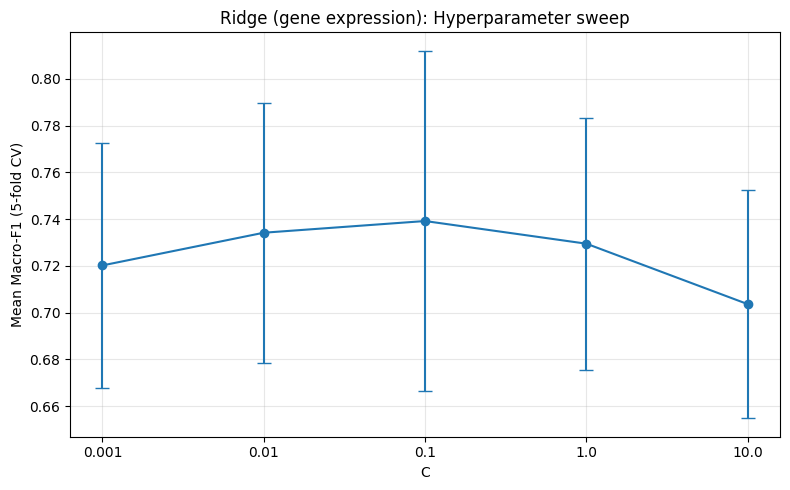

In [6]:
def make_ridge_constructor(C):
    def constructor():
        return LogisticRegression(
            penalty='l2', solver='lbfgs', C=C,
            class_weight='balanced', max_iter=5000, random_state=42
        )
    return constructor

C_values = [0.001, 0.01, 0.1, 1.0, 10.0]

ridge_results = hyperparameter_sweep(
    param_name='C', param_values=C_values,
    model_constructor_fn=make_ridge_constructor,
    fold_data=fold_data, model_name='Ridge (gene expression)',
    use_pathology=False
)

In [7]:
best_C_ridge = 0.1

def ridge_final_constructor():
    return LogisticRegression(
        penalty='l2', solver='lbfgs', C=best_C_ridge,
        class_weight='balanced', max_iter=5000, random_state=42
    )

ridge_mean_f1, ridge_std_f1, ridge_fold_scores, ridge_predictions = evaluate_model_across_folds(
    ridge_final_constructor, fold_data, use_pathology=False
)

print(f"Ridge final (C={best_C_ridge}): mean macro-F1={ridge_mean_f1:.4f} (+/- {ridge_std_f1:.4f})")

model_results['Ridge'] = {
    'mean_macro_f1': ridge_mean_f1,
    'std_macro_f1': ridge_std_f1,
    'fold_scores': ridge_fold_scores,
    'predictions': ridge_predictions,
    'best_params': {'C': best_C_ridge}
}

print("\nPer-class report (aggregated across folds):")
all_y_true = np.concatenate([p[0] for p in ridge_predictions])
all_y_pred = np.concatenate([p[1] for p in ridge_predictions])
print(classification_report(all_y_true, all_y_pred, zero_division=0))

Ridge final (C=0.1): mean macro-F1=0.7392 (+/- 0.0729)

Per-class report (aggregated across folds):
              precision    recall  f1-score   support

        ABMR       0.83      0.83      0.83       326
       Mixed       0.52      0.52      0.52        27
          NR       0.93      0.92      0.92       774
        TCMR       0.68      0.73      0.70        81

    accuracy                           0.88      1208
   macro avg       0.74      0.75      0.74      1208
weighted avg       0.88      0.88      0.88      1208



=== Linear kernel ===
C=0.01: mean macro-F1=0.7524 (+/- 0.0496)
C=0.1: mean macro-F1=0.7540 (+/- 0.0508)
C=1.0: mean macro-F1=0.7540 (+/- 0.0508)
C=10.0: mean macro-F1=0.7540 (+/- 0.0508)


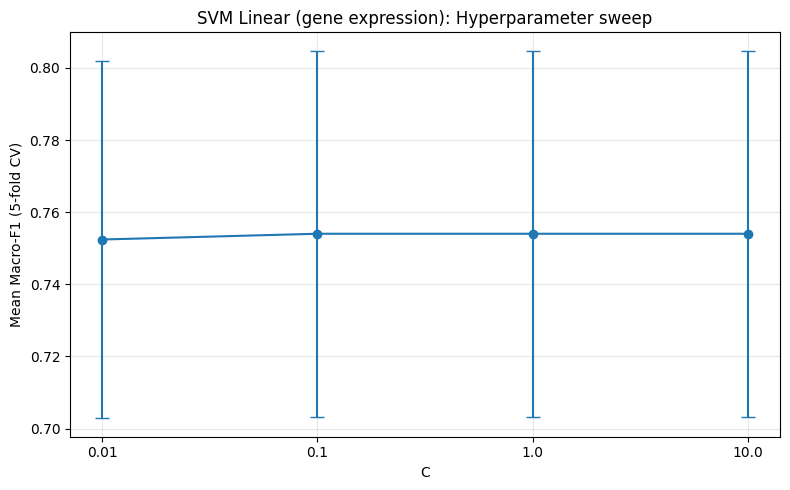


=== RBF kernel ===
C=0.01: mean macro-F1=0.1667 (+/- 0.0649)
C=0.1: mean macro-F1=0.5896 (+/- 0.0406)
C=1.0: mean macro-F1=0.6702 (+/- 0.0277)
C=10.0: mean macro-F1=0.6924 (+/- 0.0246)


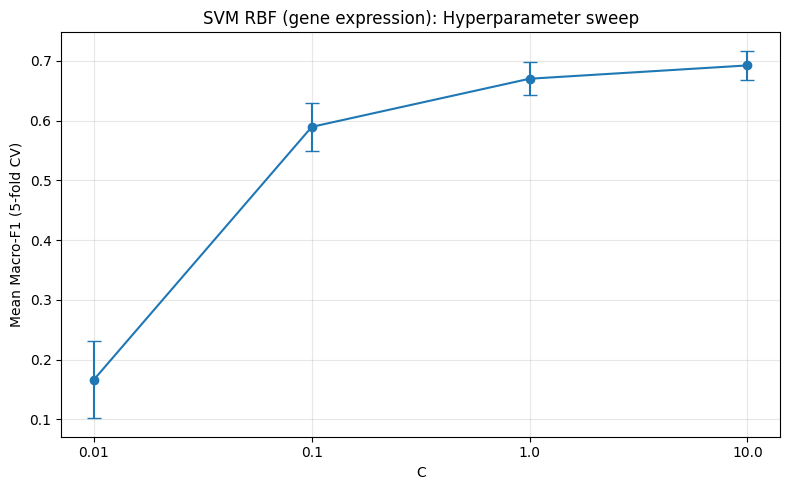

In [8]:
from sklearn.svm import SVC

def make_svm_constructor(C, kernel='linear'):
    def constructor():
        return SVC(
            C=C, kernel=kernel,
            class_weight='balanced', random_state=42
        )
    return constructor

C_values = [0.01, 0.1, 1.0, 10.0]

print("=== Linear kernel ===")
svm_linear_results = hyperparameter_sweep(
    param_name='C', param_values=C_values,
    model_constructor_fn=lambda C: make_svm_constructor(C, kernel='linear'),
    fold_data=fold_data, model_name='SVM Linear (gene expression)',
    use_pathology=False
)

print("\n=== RBF kernel ===")
svm_rbf_results = hyperparameter_sweep(
    param_name='C', param_values=C_values,
    model_constructor_fn=lambda C: make_svm_constructor(C, kernel='rbf'),
    fold_data=fold_data, model_name='SVM RBF (gene expression)',
    use_pathology=False
)

In [9]:
best_C_svm = 0.1

def svm_final_constructor():
    return SVC(
        C=best_C_svm, kernel='linear',
        class_weight='balanced', random_state=42
    )

svm_mean_f1, svm_std_f1, svm_fold_scores, svm_predictions = evaluate_model_across_folds(
    svm_final_constructor, fold_data, use_pathology=False
)

print(f"SVM final (linear, C={best_C_svm}): mean macro-F1={svm_mean_f1:.4f} (+/- {svm_std_f1:.4f})")

model_results['SVM'] = {
    'mean_macro_f1': svm_mean_f1,
    'std_macro_f1': svm_std_f1,
    'fold_scores': svm_fold_scores,
    'predictions': svm_predictions,
    'best_params': {'C': best_C_svm, 'kernel': 'linear'}
}

print("\nPer-class report (aggregated across folds):")
all_y_true = np.concatenate([p[0] for p in svm_predictions])
all_y_pred = np.concatenate([p[1] for p in svm_predictions])
print(classification_report(all_y_true, all_y_pred, zero_division=0))

SVM final (linear, C=0.1): mean macro-F1=0.7540 (+/- 0.0508)

Per-class report (aggregated across folds):
              precision    recall  f1-score   support

        ABMR       0.80      0.81      0.81       326
       Mixed       0.70      0.52      0.60        27
          NR       0.91      0.91      0.91       774
        TCMR       0.71      0.74      0.72        81

    accuracy                           0.87      1208
   macro avg       0.78      0.75      0.76      1208
weighted avg       0.87      0.87      0.87      1208



max_depth=5: mean macro-F1=0.6338 (+/- 0.0497)
max_depth=10: mean macro-F1=0.6562 (+/- 0.0138)
max_depth=20: mean macro-F1=0.6666 (+/- 0.0592)
max_depth=None: mean macro-F1=0.6394 (+/- 0.0627)


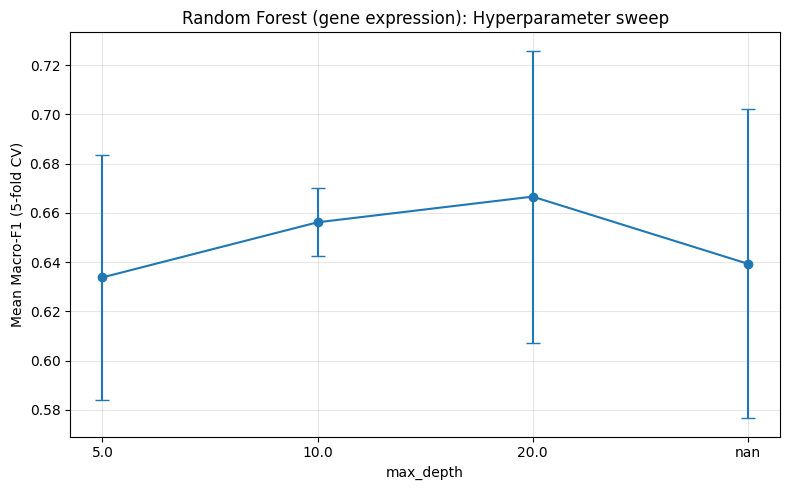

In [10]:
from sklearn.ensemble import RandomForestClassifier

def make_rf_constructor(max_depth, n_estimators=300):
    def constructor():
        return RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            class_weight='balanced', random_state=42, n_jobs=-1
        )
    return constructor

max_depth_values = [5, 10, 20, None]  # None = unlimited depth

rf_depth_results = hyperparameter_sweep(
    param_name='max_depth', param_values=max_depth_values,
    model_constructor_fn=make_rf_constructor,
    fold_data=fold_data, model_name='Random Forest (gene expression)',
    use_pathology=False
)

n_estimators=100: mean macro-F1=0.6770 (+/- 0.0430)
n_estimators=300: mean macro-F1=0.6666 (+/- 0.0592)
n_estimators=500: mean macro-F1=0.6573 (+/- 0.0715)
n_estimators=800: mean macro-F1=0.6471 (+/- 0.0549)


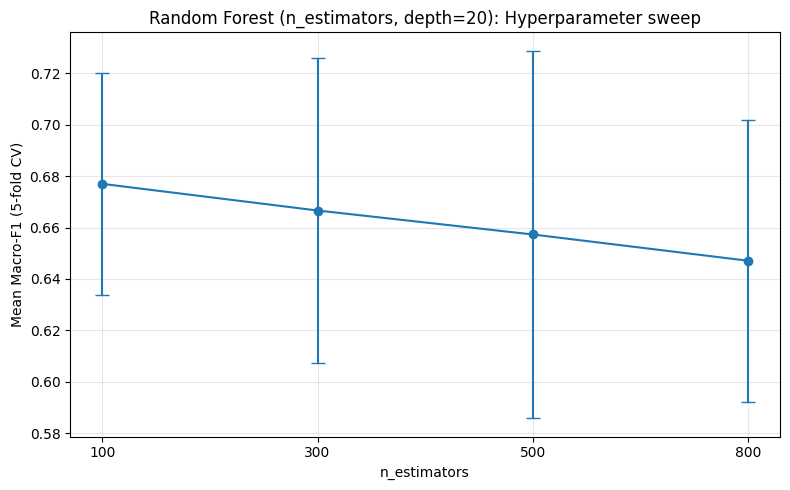

In [11]:
def make_rf_estimators_constructor(n_estimators, max_depth=20):
    def constructor():
        return RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            class_weight='balanced', random_state=42, n_jobs=-1
        )
    return constructor

n_estimators_values = [100, 300, 500, 800]

rf_estimators_results = hyperparameter_sweep(
    param_name='n_estimators', param_values=n_estimators_values,
    model_constructor_fn=make_rf_estimators_constructor,
    fold_data=fold_data, model_name='Random Forest (n_estimators, depth=20)',
    use_pathology=False
)

In [12]:
best_n_estimators_rf = 100
best_max_depth_rf = 20

def rf_final_constructor():
    return RandomForestClassifier(
        n_estimators=best_n_estimators_rf, max_depth=best_max_depth_rf,
        class_weight='balanced', random_state=42, n_jobs=-1
    )

rf_mean_f1, rf_std_f1, rf_fold_scores, rf_predictions = evaluate_model_across_folds(
    rf_final_constructor, fold_data, use_pathology=False
)

print(f"RF final (n_estimators={best_n_estimators_rf}, max_depth={best_max_depth_rf}): "
      f"mean macro-F1={rf_mean_f1:.4f} (+/- {rf_std_f1:.4f})")

model_results['Random Forest'] = {
    'mean_macro_f1': rf_mean_f1,
    'std_macro_f1': rf_std_f1,
    'fold_scores': rf_fold_scores,
    'predictions': rf_predictions,
    'best_params': {'n_estimators': best_n_estimators_rf, 'max_depth': best_max_depth_rf}
}

print("\nPer-class report (aggregated across folds):")
all_y_true = np.concatenate([p[0] for p in rf_predictions])
all_y_pred = np.concatenate([p[1] for p in rf_predictions])
print(classification_report(all_y_true, all_y_pred, zero_division=0))

RF final (n_estimators=100, max_depth=20): mean macro-F1=0.6770 (+/- 0.0430)

Per-class report (aggregated across folds):
              precision    recall  f1-score   support

        ABMR       0.83      0.76      0.79       326
       Mixed       0.70      0.26      0.38        27
          NR       0.90      0.94      0.92       774
        TCMR       0.63      0.64      0.63        81

    accuracy                           0.86      1208
   macro avg       0.76      0.65      0.68      1208
weighted avg       0.85      0.86      0.85      1208



max_depth=3, lr=0.1: mean macro-F1=0.7998 (+/- 0.0285)
max_depth=3, lr=0.3: mean macro-F1=0.8035 (+/- 0.0295)
max_depth=5, lr=0.1: mean macro-F1=0.7709 (+/- 0.0400)
max_depth=5, lr=0.3: mean macro-F1=0.7611 (+/- 0.0389)
max_depth=7, lr=0.1: mean macro-F1=0.7510 (+/- 0.0340)


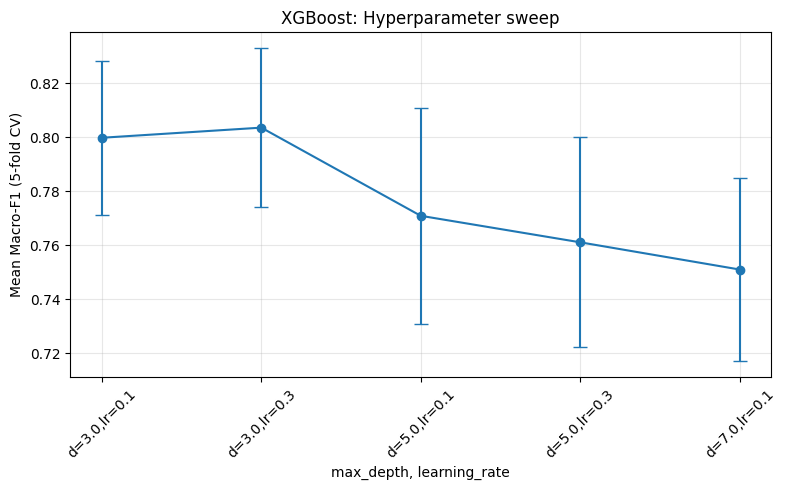

In [13]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

def make_xgb_constructor(max_depth, learning_rate, n_estimators=200):
    def constructor():
        return XGBClassifier(
            max_depth=max_depth, learning_rate=learning_rate, n_estimators=n_estimators,
            objective='multi:softmax', num_class=4,
            random_state=42, n_jobs=-1, eval_metric='mlogloss'
        )
    return constructor

def evaluate_xgb_across_folds(model_constructor, fold_data):
    """XGBoost needs numeric labels and sample_weight for class imbalance, so a custom loop."""
    fold_f1_scores = []
    fold_predictions = []
    le = LabelEncoder()
    le.fit(['NR', 'TCMR', 'ABMR', 'Mixed'])

    for fold in range(5):
        X_train = fold_data[fold]['gene_train'].values
        X_val = fold_data[fold]['gene_val'].values
        y_train = fold_data[fold]['y_train']
        y_val = fold_data[fold]['y_val']

        y_train_enc = le.transform(y_train)
        y_val_enc = le.transform(y_val)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

        model = model_constructor()
        model.fit(X_train, y_train_enc, sample_weight=sample_weights)
        preds_enc = model.predict(X_val)
        preds = le.inverse_transform(preds_enc)

        macro_f1 = f1_score(y_val, preds, average='macro')
        fold_f1_scores.append(macro_f1)
        fold_predictions.append((y_val, preds))

    return np.mean(fold_f1_scores), np.std(fold_f1_scores), fold_f1_scores, fold_predictions


depth_lr_combos = [(3, 0.1), (3, 0.3), (5, 0.1), (5, 0.3), (7, 0.1)]

xgb_sweep_results = []
for depth, lr in depth_lr_combos:
    constructor = make_xgb_constructor(max_depth=depth, learning_rate=lr)
    mean_f1, std_f1, _, _ = evaluate_xgb_across_folds(constructor, fold_data)
    xgb_sweep_results.append({'max_depth': depth, 'learning_rate': lr, 'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1})
    print(f"max_depth={depth}, lr={lr}: mean macro-F1={mean_f1:.4f} (+/- {std_f1:.4f})")

xgb_results_df = pd.DataFrame(xgb_sweep_results)

plt.figure(figsize=(8, 5))
labels = [f"d={r['max_depth']},lr={r['learning_rate']}" for _, r in xgb_results_df.iterrows()]
plt.errorbar(labels, xgb_results_df['mean_macro_f1'], yerr=xgb_results_df['std_macro_f1'], marker='o', capsize=5)
plt.xlabel('max_depth, learning_rate')
plt.ylabel('Mean Macro-F1 (5-fold CV)')
plt.title('XGBoost: Hyperparameter sweep')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
best_depth_xgb = 3
best_lr_xgb = 0.3

def xgb_final_constructor():
    return XGBClassifier(
        max_depth=best_depth_xgb, learning_rate=best_lr_xgb, n_estimators=200,
        objective='multi:softmax', num_class=4,
        random_state=42, n_jobs=-1, eval_metric='mlogloss'
    )

xgb_mean_f1, xgb_std_f1, xgb_fold_scores, xgb_predictions = evaluate_xgb_across_folds(
    xgb_final_constructor, fold_data
)

print(f"XGBoost final (max_depth={best_depth_xgb}, lr={best_lr_xgb}): "
      f"mean macro-F1={xgb_mean_f1:.4f} (+/- {xgb_std_f1:.4f})")

model_results['XGBoost'] = {
    'mean_macro_f1': xgb_mean_f1,
    'std_macro_f1': xgb_std_f1,
    'fold_scores': xgb_fold_scores,
    'predictions': xgb_predictions,
    'best_params': {'max_depth': best_depth_xgb, 'learning_rate': best_lr_xgb}
}

print("\nPer-class report (aggregated across folds):")
all_y_true = np.concatenate([p[0] for p in xgb_predictions])
all_y_pred = np.concatenate([p[1] for p in xgb_predictions])
print(classification_report(all_y_true, all_y_pred, zero_division=0))

XGBoost final (max_depth=3, lr=0.3): mean macro-F1=0.8035 (+/- 0.0295)

Per-class report (aggregated across folds):
              precision    recall  f1-score   support

        ABMR       0.84      0.83      0.84       326
       Mixed       0.78      0.67      0.72        27
          NR       0.93      0.93      0.93       774
        TCMR       0.72      0.78      0.75        81

    accuracy                           0.89      1208
   macro avg       0.82      0.80      0.81      1208
weighted avg       0.89      0.89      0.89      1208

